In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
import rfitools
import numba as nb
import importlib
importlib.reload(rfitools)
import time


In [2]:
from pyuvdata import UVData

In [3]:
filename = "/scratch/achokshi/pyuvsim/uvh5/albatros_sim_ateam_20MHz_256chans_1SD_0.5s_uni.uvh5"
uvd = UVData.from_file(filename, read_data = True, frequencies=[19872000,])

In [4]:
with np.load('vis_dump.npz') as f:
    vis=f['vis']
    cnt=f['cnt']
    tstart=f['tstart']
    deltat=f['deltat']
    deltaf=f['deltaf']

FileNotFoundError: [Errno 2] No such file or directory: 'vis_dump.npz'

In [ ]:
vis.nbytes/1e3

688.8

In [ ]:
deltat, deltaf

(array(1.07374182), array(4768.37158203))

In [ ]:
fstart = 360*250e6/4096

In [ ]:
fstart

21972656.25

In [27]:
vis.shape, vis.flags

((10, 410, 21),
   C_CONTIGUOUS : True
   F_CONTIGUOUS : False
   OWNDATA : True
   WRITEABLE : True
   ALIGNED : True
   WRITEBACKIFCOPY : False)

In [28]:
nant=7
triu_idx=np.triu_indices(nant,k=1)
nbl = len(triu_idx[0])

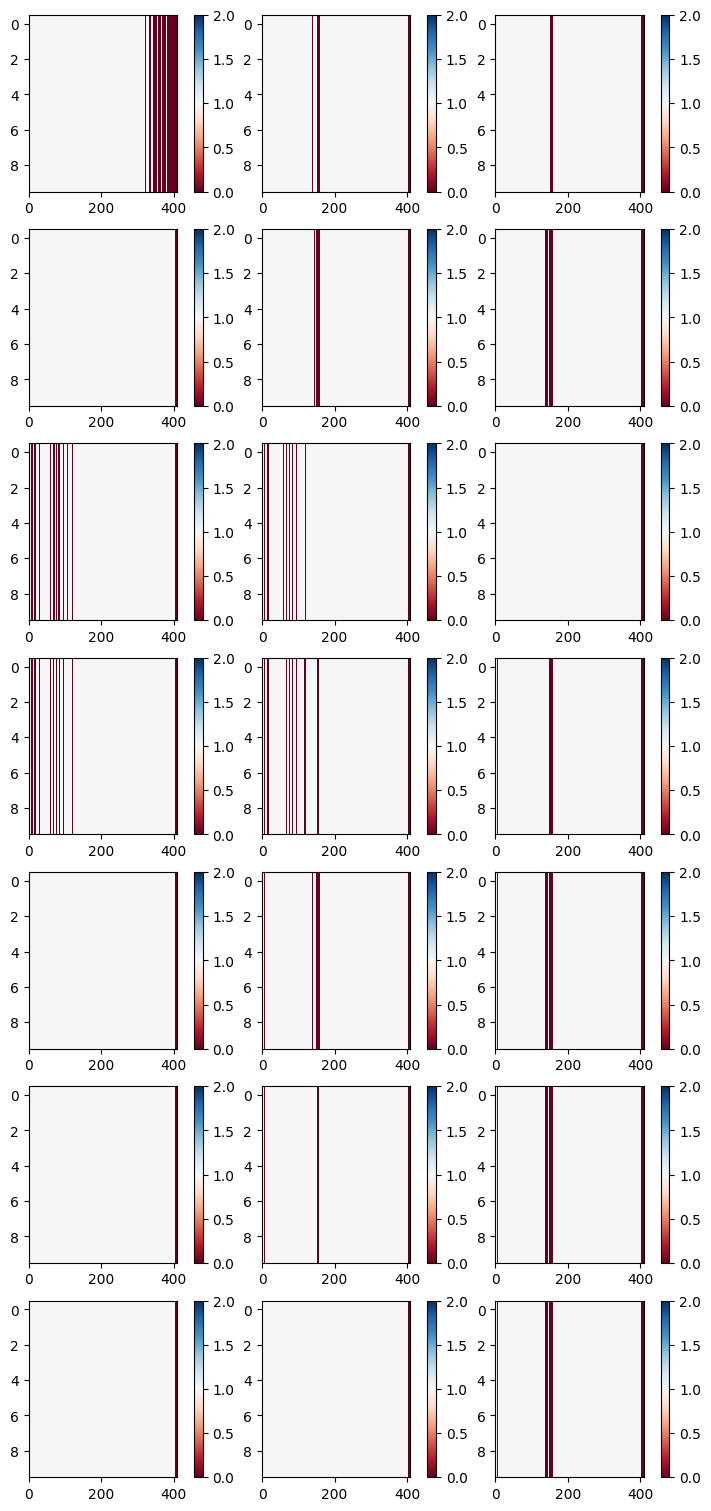

In [69]:
fig,ax = plt.subplots(7,3, layout='constrained')
fig.set_size_inches(7,15)
ax=np.ravel(ax)
pnum=0
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    # ax[pnum].set_title(f"{antmap[ai]}-{antmap[aj]} bl_id={(i)}")
    # img=ax[pnum].imshow(np.angle(vis[:,:,i]),aspect='auto',cmap='RdBu',interpolation='none')
    img=ax[pnum].imshow(cnt[:,:,i]>0,aspect='auto',cmap='RdBu',interpolation='none',vmin=0, vmax=2)
    cbar=plt.colorbar(img,ax=ax[pnum])
    # ax[pnum].set_ylim(600,800)
    # ax[pnum].set_ylim(2000,4000)
    pnum+=1

Steps:
1. Generate delays for all pixels for all antenna

In [11]:
vis_avg = np.mean(vis,axis=0)
cnt_avg = np.sum(cnt,axis=0)
print(vis_avg.shape)

(410, 21)


In [5]:
coords = {
        0: [79.417161473, -90.767238685, 187.9577], #MARS1
        1: [79.417198047, -90.758739192, 183.0684], #MARS2
        2: [79.388456412, -91.019202963, 25.1938], #CSA
        3: [79.418302573, -90.667395452, 59.6242], #Mars 5
        4: [79.397984238, -90.799842408, 41.6994], #Mars 6
        5: [79.411474117, -90.695266129, 31.6314], #Mars 7
        6: [79.443757694, -90.718202634, 414.9131] #MARS8
    }
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
ant0=EarthLocation.from_geodetic(lat=coords[0][0], lon=coords[0][1], height=coords[0][2])

In [4]:
uvd.time_array

array([2460676.5       , 2460676.5       , 2460676.5       , ...,
       2460677.49726273, 2460677.49726273, 2460677.49726273],
      shape=(6203808,))

In [19]:
sim_ncross = len(np.unique(uvd.baseline_array))
len(uvd.time_array[::sim_ncross])

172328

In [20]:
sim_obstime = Time(uvd.time_array[::sim_ncross],format="jd",scale="utc")
sim_lst = sim_obstime.sidereal_time('apparent', longitude=ant0.lon)

In [21]:
sim_lst

<Longitude [0.67550386, 0.67564313, 0.6757824 , ..., 0.67506301,
            0.67520227, 0.67534155] hourangle>

In [29]:
NSIDE=1024
t_idx = 0
NPIX=hp.nside2npix(NSIDE)
print("resol", hp.nside2resol(NSIDE,arcmin=True), "npix", NPIX)
co_dec,ra=hp.pix2ang(NSIDE,np.arange(NPIX))
dec=np.pi/2-co_dec

# obstime=Time(tstart+vis.shape[0] * deltat/2,format="unix",scale="utc")
obstime=Time(tstart+t_idx*deltat+deltat/2,format="unix",scale="utc")
print(obstime)
src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
altaz =src.transform_to(AltAz(location=ant0,obstime=obstime))

resol 3.435486411817406 npix 12582912
1753264834.1802247


In [37]:
real_lst = obstime.sidereal_time('apparent',longitude=ant0.lon)
real_lst

<Longitude 0.05156559 hourangle>

In [39]:
lst_idx = np.argmin(np.abs(real_lst-sim_lst))

In [40]:
uvd.data_array.shape

(6203808, 1, 4)

In [42]:
uvd.time_array[::sim_ncross][lst_idx]

np.float64(2460677.4713425925)

In [43]:
Time(2460677.4713425925,format="jd",scale="utc").sidereal_time('apparent', longitude=ant0.lon)

<Longitude 0.05155497 hourangle>

In [50]:
uvd.select(antenna_nums=[0,1,3,4,5,6,7],times=[2460677.4713425925,],polarizations=['ee','nn'])

In [53]:
uvd.data_array.flags

  C_CONTIGUOUS : False
  F_CONTIGUOUS : False
  OWNDATA : False
  WRITEABLE : True
  ALIGNED : True
  WRITEBACKIFCOPY : False

In [79]:
sim_data = uvd.data_array.copy()

In [80]:
sim_data = np.mean(sim_data,axis=2)

sim_vis = np.zeros((1,nbl),dtype='complex128')
idx=0
for i, pair in enumerate(uvd.get_antpairs()):
    if pair[0]==pair[1]:
        continue
    else:
        sim_vis[0,idx]=sim_data[i,0]
    idx+=1

In [76]:
sim_data

array([[ 55263.18341966    +0.j        ],
       [ 28380.97407401+13617.61489418j],
       [-34087.70878719-12468.92567789j],
       [-26144.1245055 +43354.630347j  ],
       [-15667.37820936+31675.43846717j],
       [-20403.69240141+41860.18069208j],
       [ 34951.81398964-14297.75693139j],
       [ 55263.18341966    +0.j        ],
       [-20235.97645344 -4307.1200017j ],
       [ -5820.28279922+36169.35738647j],
       [ -4303.93538004+46703.3811144j ],
       [  3311.83424525+24628.10624418j],
       [ 31284.57163912-27575.5428306j ],
       [ 55263.18341966    +0.j        ],
       [  2550.78451138-29232.62273748j],
       [ -6551.34716452-30181.77785284j],
       [  2082.68492986-31787.01396924j],
       [-14007.27707423+20985.67745902j],
       [ 55263.18341966    +0.j        ],
       [ 38715.03367945 -8615.81168552j],
       [ 43904.19600333 -3531.7267261j ],
       [-33411.78361002-25810.17162282j],
       [ 55263.18341966    +0.j        ],
       [ 29875.89850062  -366.4591

In [81]:
sim_vis

array([[ 28380.97407401+13617.61489418j, -34087.70878719-12468.92567789j,
        -26144.1245055 +43354.630347j  , -15667.37820936+31675.43846717j,
        -20403.69240141+41860.18069208j,  34951.81398964-14297.75693139j,
        -20235.97645344 -4307.1200017j ,  -5820.28279922+36169.35738647j,
         -4303.93538004+46703.3811144j ,   3311.83424525+24628.10624418j,
         31284.57163912-27575.5428306j ,   2550.78451138-29232.62273748j,
         -6551.34716452-30181.77785284j,   2082.68492986-31787.01396924j,
        -14007.27707423+20985.67745902j,  38715.03367945 -8615.81168552j,
         43904.19600333 -3531.7267261j , -33411.78361002-25810.17162282j,
         29875.89850062  -366.45919654j, -23162.32486162-30364.38570296j,
        -26629.90757991-29231.37787683j]])

In [82]:
altaz

<SkyCoord (AltAz: obstime=1753264834.1802247, location=(-15736.856934023037, -1175125.301635555, 6248101.174265215) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    [(1.82472677e-01,  79.3118883 ), (1.84078707e-01,  79.24728142),
     (3.59837806e+02,  79.24679174), ..., (1.79806190e+02, -79.3016997 ),
     (1.80154233e+02, -79.30222345), (1.80156005e+02, -79.23761416)]>

In [83]:
@nb.njit(parallel=True)
def geo_delay(bls,alt,az):
    npix = alt.shape[0]
    nbl = bls.shape[0] #each row is x, y, z
    delays = np.empty((nbl,npix),dtype='float64')
    c=299792458
    for pix in nb.prange(npix):
        cos_alt = np.cos(np.pi * alt[pix] / 180)
        sin_alt = np.sin(np.pi * alt[pix] / 180)
        cos_az = np.cos(np.pi * az[pix] / 180)
        sin_az = np.sin(np.pi * az[pix] / 180)
        for bl in range(nbl):
            ea,no,up = bls[bl]
            p = 0
            p += sin_az*cos_alt * ea #east
            p += cos_az*cos_alt * no #north
            p += sin_alt * up #up
            delays[bl, pix] = p/c
    return delays

In [84]:
bl_enus = rfitools.get_all_bls(coords,np.arange(len(coords)))
bl_enus1 =  rfitools.get_all_bls(coords,np.arange(len(coords)), refonly=True)

(21, 3)
(7, 3)


In [20]:
bl_enus1

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.74337851e+02,  4.09653097e+00, -4.89167617e+00],
       [-5.18190794e+03, -3.19389890e+03, -1.65659363e+02],
       [ 2.04768856e+03,  1.29165542e+02, -1.28662439e+02],
       [-6.69938365e+02, -2.14107676e+03, -1.46651654e+02],
       [ 1.47702316e+03, -6.34117995e+02, -1.56528194e+02],
       [ 1.00334704e+03,  2.97024217e+03,  2.26187263e+02]])

dtype('float64')

In [86]:
delays = geo_delay(bl_enus, altaz.alt.value, altaz.az.value)

In [93]:
sim_delays1 = geo_delay(uvd.get_enu_data_ants()[0], altaz.alt.value, altaz.az.value)

In [94]:
sim_delays1.shape

(7, 12582912)

In [95]:
sim_delays = sim_delays1[triu_idx[1],:]-sim_delays1[triu_idx[0],:]

In [97]:
sim_delays.shape, delays.shape

((21, 12582912), (21, 12582912))

In [92]:
idx=0
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    print(np.max(np.abs(delays[i] - (delays1[aj]-delays1[ai]))))

0.0
0.0
0.0
0.0
0.0
0.0
1.6940658945086007e-20
3.3881317890172014e-21
5.082197683525802e-21
3.3881317890172014e-21
6.776263578034403e-21
1.3552527156068805e-20
1.3552527156068805e-20
1.3552527156068805e-20
1.6940658945086007e-20
5.082197683525802e-21
3.8116482626443515e-21
6.776263578034403e-21
5.082197683525802e-21
1.3552527156068805e-20
8.470329472543003e-21


In [20]:
#baseline lengths
bl_lengths = np.sqrt(np.sum(bl_enus*bl_enus,axis=1))
for i in range(nbl):
    ai = triu_idx[0][i]
    aj = triu_idx[1][i]
    print(antmap[ai], antmap[aj], i,ai,aj, bl_lengths[i])

MARS1 MARS2 0 0 1 174.45456775051662
MARS1 MARS4 1 0 2 6089.384461074008
MARS1 MARS5 2 0 3 2055.7884567985097
MARS1 MARS6 3 0 4 2248.2290395629816
MARS1 MARS7 4 0 5 1614.993536696582
MARS1 MARS8 5 0 6 3143.2792581319386
MARS2 MARS4 6 1 2 6240.3838025376035
MARS2 MARS5 7 1 3 1881.5962163339905
MARS2 MARS6 8 1 4 2309.689734452764
MARS2 MARS7 9 1 5 1458.5268016563846
MARS2 MARS8 10 1 6 3088.474324240012
MARS4 MARS5 11 2 3 7956.833009844907
MARS4 MARS6 12 2 4 4633.21326925574
MARS4 MARS7 13 2 5 7133.9978322114575
MARS4 MARS8 14 2 6 8741.141688683856
MARS5 MARS6 15 3 4 3541.1607982782593
MARS5 MARS7 16 3 5 953.4344496617705
MARS5 MARS8 17 3 6 3047.6686048967063
MARS6 MARS7 18 4 5 2623.064250068337
MARS6 MARS8 19 4 6 5391.147752404277
MARS7 MARS8 20 5 6 3655.4414760084646


In [17]:
fringes = np.exp(2j*np.pi*21e6*delays)

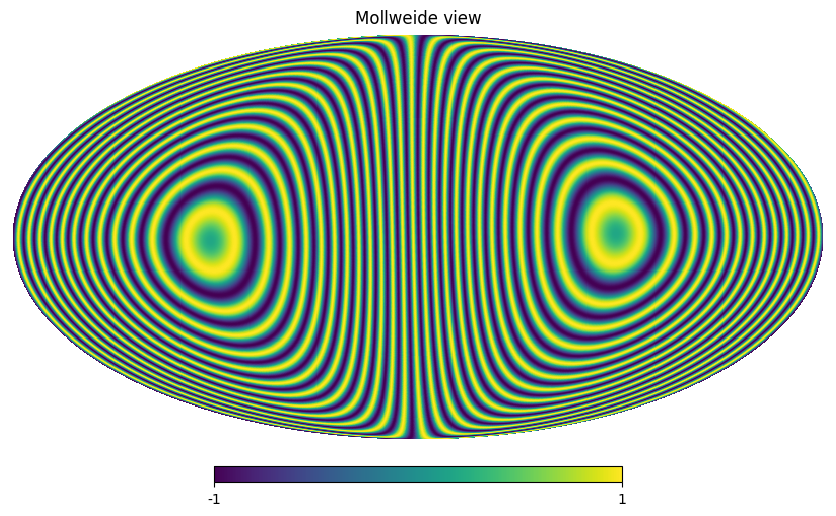

In [24]:
# hp.orthview(fringes[0,:].real, rot=(0,90),half_sky=True)
hp.mollview(fringes[0,:].real)

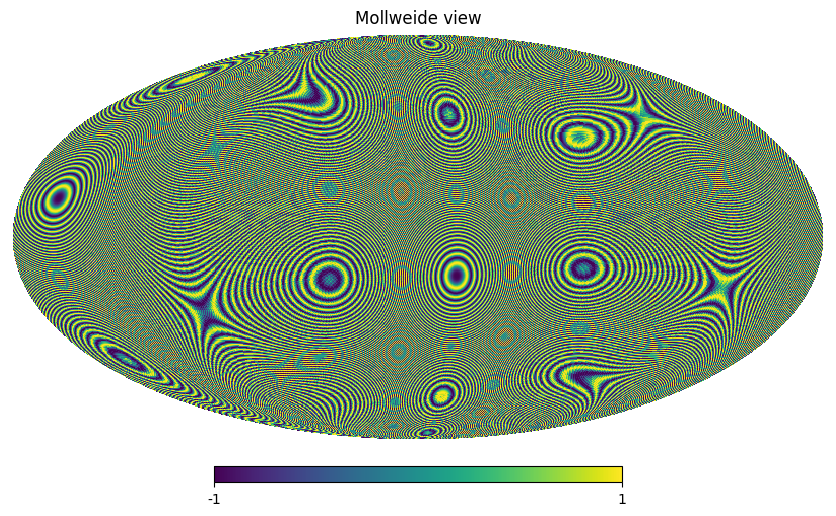

In [28]:
# hp.orthview(fringes[3,:].real, rot=(0,90),half_sky=True)
hp.mollview(fringes[3,:].real)

In [97]:
#for one pixel
dd = delays1[:,0]
delays[:,0] - (dd[triu_idx[1]]-dd[triu_idx[0]]) # a numpy trick to generate per baseline delays

In [31]:
x =np.arange(10)


In [207]:
# good_bls = [2,3,4,7,8,9,10,16,17,18]
# good_bls = [5,10,17,19,20]
good_bls = np.arange(1,nbl)
print(good_bls)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [208]:
good_freq_idx = np.bitwise_and.reduce(cnt[t_idx,:,1:]>0, axis=1) #across all baselines, excluding MARS1-2 because we wont use it

In [209]:
good_freq_idx = np.bitwise_and.reduce(cnt_avg[:,good_bls]>10, axis=1)

334


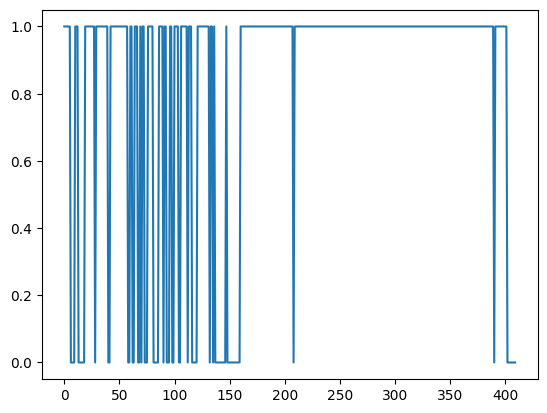

In [210]:
plt.plot(good_freq_idx)
print(np.sum(good_freq_idx))

In [211]:
freqs = np.arange(vis.shape[1]) * deltaf + fstart #Hz
good_freqs = freqs[good_freq_idx].copy()
print(len(good_freqs))

334


In [212]:
delaysT = delays[1:,:].T.copy() #exclude MARS1-2
data = vis[t_idx, good_freq_idx, 1:].copy() #exclude MARS1-2

In [178]:
delaysT = delays[good_bls,:].T.copy() #exclude MARS1-2
data = vis_avg[:, good_bls][good_freq_idx, :].copy() #exclude MARS1-2

In [213]:
data.shape, delaysT.shape

((334, 20), (12582912, 20))

In [201]:
good_freqs.shape

(334,)

In [118]:
@nb.njit(parallel=True)
def get_map(data,freqs,delays,npix):
    print(data.shape, freqs.shape, delays.shape)
    map1 = np.zeros(npix, dtype=np.complex128)
    nfreq, nbl = data.shape
    N_vis = nfreq * nbl
    for p in nb.prange(npix):
        pixel_sum = 0j
        for f in range(nfreq):
            nu = freqs[f]
            for b in range(nbl):
                tau = delays[p, b] #delay shape is npix, nbl for CPU

                # Calculate the fringe factor for this specific visibility
                fringe = np.exp(-2j * np.pi * nu * tau)
                
                # Accumulate the dot product
                pixel_sum += fringe * data[f, b]
        
        # Calculate the mean and assign to the pixel map
        map1[p] = pixel_sum / N_vis
    return map1

In [99]:
NPIX

12582912

In [104]:
sim_delaysT = sim_delays.T.copy()

In [105]:
sim_vis.shape, sim_delaysT.shape

((1, 21), (12582912, 21))

In [119]:
sim_map = get_map(sim_vis,np.asarray([19872000],dtype='float64'),sim_delaysT,NPIX)

(1, 21) (1,) (12582912, 21)


In [109]:
sim_map.shape

(12582912,)

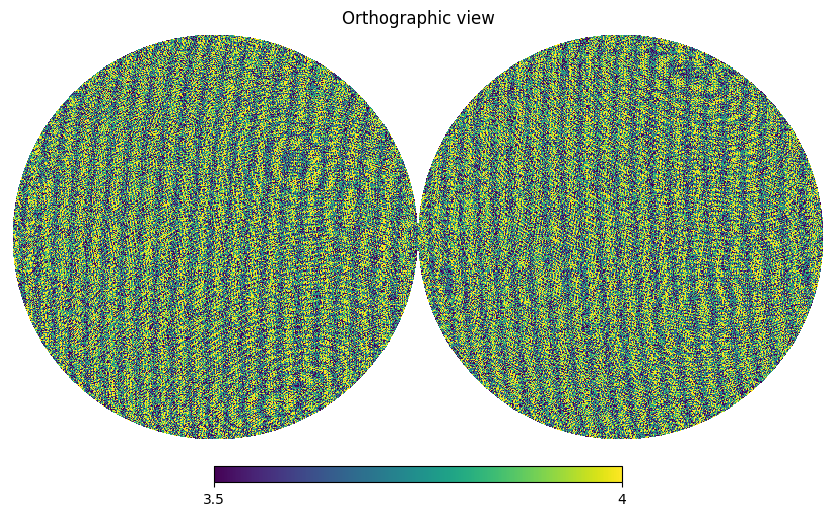

In [120]:
hp.orthview(np.log10(np.abs(sim_map)),rot=(0,90),min=3.5,max=4)

In [132]:
delays-sim_delays

array([[ 2.35450217e-08,  2.35395888e-08,  2.35294144e-08, ...,
        -2.35332043e-08, -2.35433815e-08, -2.35379440e-08],
       [ 1.93130555e-08,  1.93157742e-08,  1.93019381e-08, ...,
        -1.92984927e-08, -1.93123314e-08, -1.93150465e-08],
       [ 1.62611934e-09,  1.62779680e-09,  1.62393910e-09, ...,
        -1.62219612e-09, -1.62605414e-09, -1.62773136e-09],
       ...,
       [ 1.08179771e-10,  1.08204214e-10,  1.08711465e-10, ...,
        -1.08732201e-10, -1.08224941e-10, -1.08249365e-10],
       [-3.23264352e-09, -3.23320987e-09, -3.23434705e-09, ...,
         3.23395837e-09,  3.23282149e-09,  3.23338725e-09],
       [-3.34082329e-09, -3.34141409e-09, -3.34305851e-09, ...,
         3.34269057e-09,  3.34104643e-09,  3.34163662e-09]],
      shape=(21, 12582912))

In [100]:
_ = get_map(data,good_freqs,delaysT,100)

NameError: name 'data' is not defined

In [202]:
t1=time.time()
map1 = get_map(data,good_freqs,delaysT,NPIX)
t2=time.time()
print(t2-t1)

(334, 20) (334,) (12582912, 20)
132.56445455551147


In [214]:
t1=time.time()
map2 = get_map(data,good_freqs,delaysT,NPIX)
t2=time.time()
print(t2-t1)

(334, 20) (334,) (12582912, 20)
132.34196996688843


In [222]:
# big loop da loop
maps = np.zeros((vis.shape[0],NPIX), dtype='complex128')
for t_idx in range(vis.shape[0]):
    obstime=Time(tstart+t_idx*deltat+deltat/2,format="unix",scale="utc")
    print(obstime)
    src = SkyCoord(ra=ra*u.rad, dec=dec*u.rad, frame='icrs')
    altaz =src.transform_to(AltAz(location=ant0,obstime=obstime))
    delays = geo_delay(bl_enus, altaz.alt.value, altaz.az.value)
    good_freq_idx = np.bitwise_and.reduce(cnt[t_idx,:,1:]>0, axis=1)
    good_freqs = freqs[good_freq_idx].copy()
    print("good freqs",len(good_freqs))
    delaysT = delays[1:,:].T.copy() #exclude MARS1-2
    data = vis[t_idx, good_freq_idx, 1:].copy() #exclude MARS1-2
    t1=time.time()
    maps[t_idx, :] = get_map(data,good_freqs,delaysT,NPIX)
    t2=time.time()
    print(t2-t1)

1753264834.1802247
good freqs 334
(334, 20) (334,) (12582912, 20)
133.02598309516907
1753264835.2539666
good freqs 334
(334, 20) (334,) (12582912, 20)
133.3397204875946
1753264836.3277082
good freqs 334
(334, 20) (334,) (12582912, 20)
134.21233415603638
1753264837.4014502
good freqs 334
(334, 20) (334,) (12582912, 20)
134.01676201820374
1753264838.475192
good freqs 334
(334, 20) (334,) (12582912, 20)
133.75442337989807
1753264839.5489337
good freqs 334
(334, 20) (334,) (12582912, 20)
134.24741435050964
1753264840.6226757
good freqs 334
(334, 20) (334,) (12582912, 20)
133.77119755744934
1753264841.6964173
good freqs 334
(334, 20) (334,) (12582912, 20)
134.27849888801575
1753264842.7701592
good freqs 334
(334, 20) (334,) (12582912, 20)
133.7721734046936
1753264843.8439012
good freqs 334
(334, 20) (334,) (12582912, 20)
134.18749356269836


In [224]:
avg_map = np.mean(maps, axis=0)

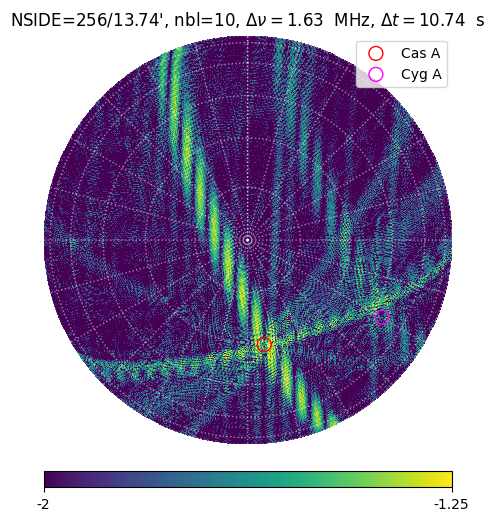

In [171]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(map1)),min=-2,max=-1.25, rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

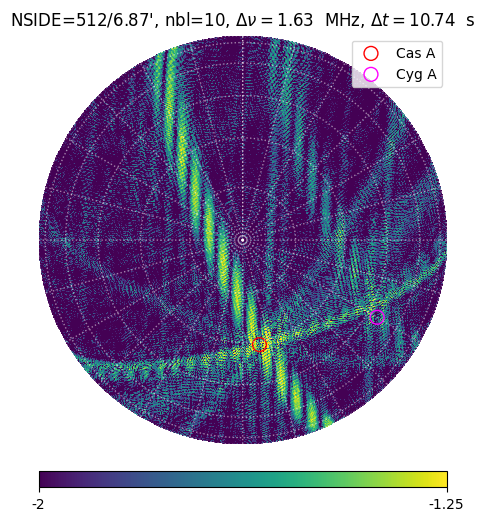

In [185]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(map1)),min=-2,max=-1.25, rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

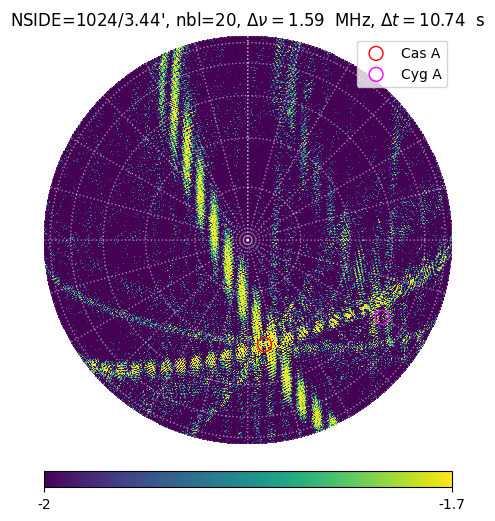

In [235]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(0,90),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A

hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

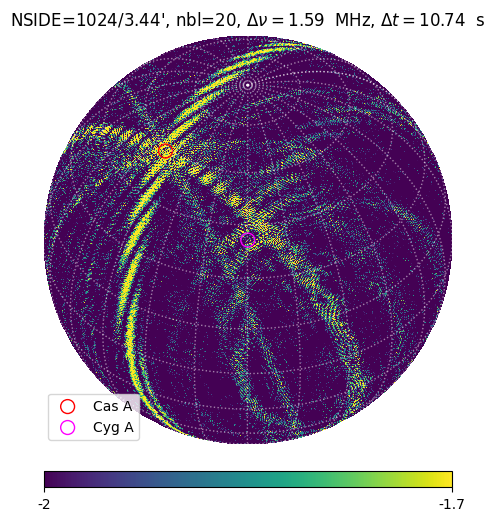

In [236]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(cyg_a.ra.deg,cyg_a.dec.deg),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')


hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

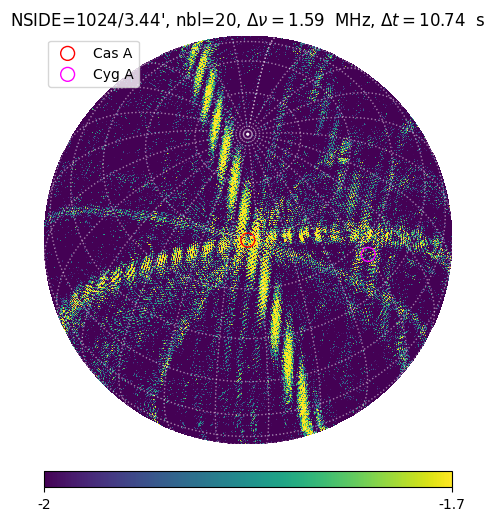

In [237]:
bw=len(good_freqs)*deltaf
title=rf"NSIDE={NSIDE}/{hp.nside2resol(NSIDE,arcmin=True):.2f}', nbl={len(good_bls)}, $\Delta \nu={bw/1e6:.2f}$  MHz, $\Delta t={deltat*vis.shape[0]:.2f}$  s"
cas_a = SkyCoord('23h23m27.94s', '58d48m42.4s', frame='icrs')
cyg_a = SkyCoord(ra='19h 59m 28.3566s', dec="40° 44′ 02.096″", frame='icrs') #Cyg A
hp.orthview(np.log10(np.abs(avg_map)),min=-2,max=-1.7, rot=(cas_a.ra.deg,cas_a.dec.deg),half_sky=True,title=title)
# hp.orthview(np.real(avg_map), min=-0.01,max=0.01,rot=(0,90),half_sky=True,title=title)
hp.graticule(dpar=15, dmer=15, color='white', alpha=0.5, ls=':')


hp.projscatter(cas_a.ra.deg, cas_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='red', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cas A')

hp.projscatter(cyg_a.ra.deg, cyg_a.dec.deg, lonlat=True, coord='C', 
               marker='o',       # Circle marker
               facecolors='none',# Hollow circle
               edgecolors='magenta', # Red outline
               s=100,            # Size of the circle
               lw=1,             # Line width
               label='Cyg A')


plt.legend()
plt.show()

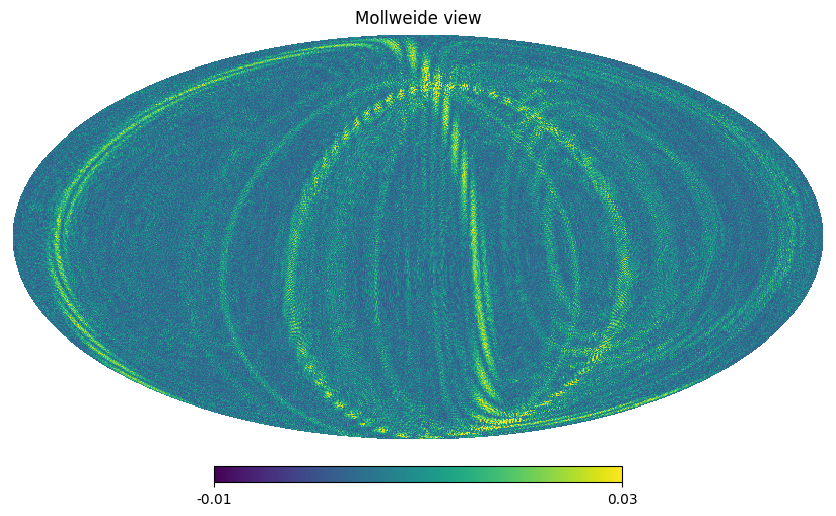

In [112]:
hp.mollview(np.abs(map1),min=-0.01,max=0.03)

## low res map with short bls

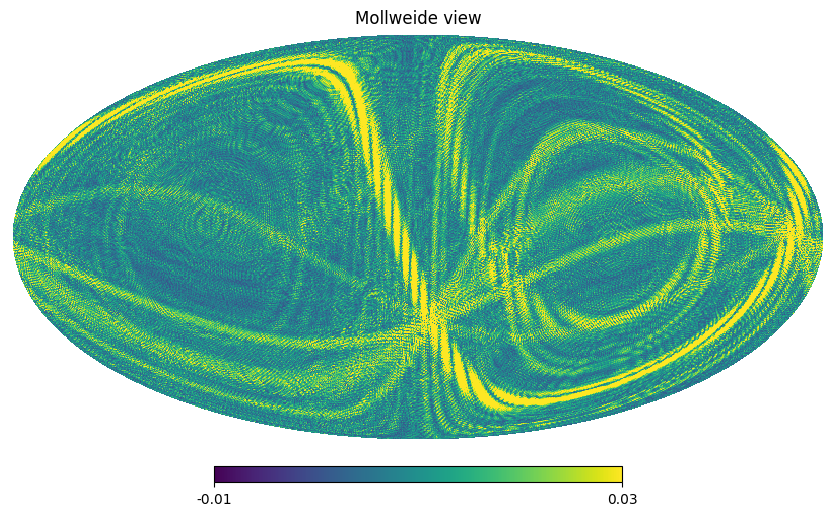

In [74]:
hp.mollview(np.abs(map1),min=-0.01,max=0.03, rot=(0,90))

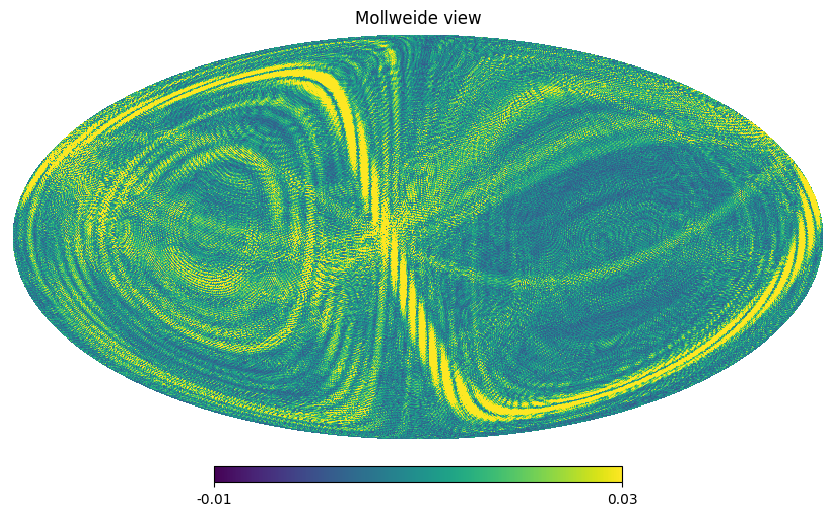

In [73]:
hp.mollview(np.abs(map2),min=-0.01,max=0.03, rot=(0,90))

## Baslines only with MARS8

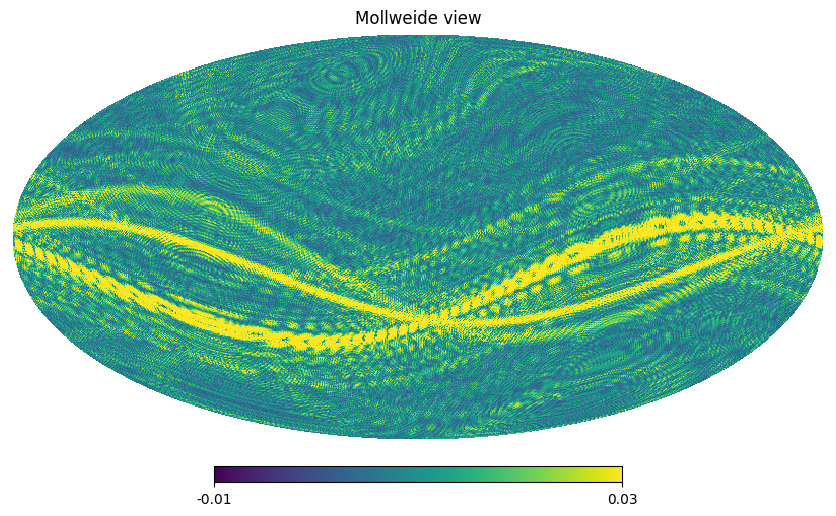

In [92]:
hp.mollview(np.abs(map1),min=-0.01,max=0.03, rot=(0,90))

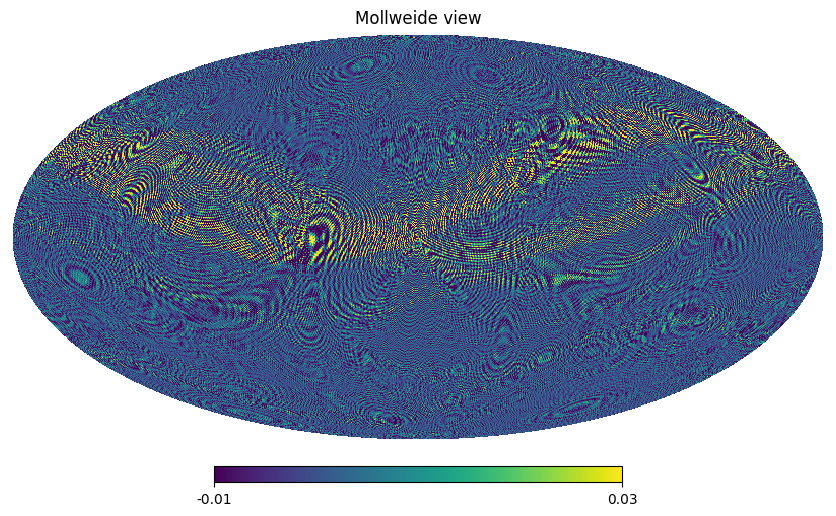

In [94]:
hp.mollview(np.real(map2),min=-0.01,max=0.03, rot=(0,90))